In [1]:
from Seq_basics_QC_utils import *
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# VIF calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Load the experimental data

In [2]:
root = '/Users/cqh/Desktop/Fig2/Linker_mini_screen/'

df_path = root+'Combined_df/'

df_var = pd.read_csv(df_path+'summary_combined_compensated_subset.csv')

# Multivariable linear regression

### Calculate the VIF value to test colinearlity in the experimental hinge sequences

In [59]:
tmp = df_var[['length', 'A', 'GS', 'EK', 'P', 'helix_panelty', 'high_corrected', 'low_corrected', 'fc_var']]
tmp.describe()

# get all the variable from the tmp
X = tmp.drop(columns=['high_corrected', 'low_corrected', 'fc_var', ])

# drop some variables see if VIF change
X = X.drop(columns=['helix_panelty'])

# Add a constant column to the independent variables DataFrame
X = add_constant(X)

# Calculate VIF for each feature
vif = pd.DataFrame()
vif['variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

  variable        VIF
0    const  20.185026
1   length   1.137259
2        A   1.120908
3       GS   2.747203
4       EK   2.331020
5        P   1.755169


### Background activation linear regression with experimental data

0.4114784347051116


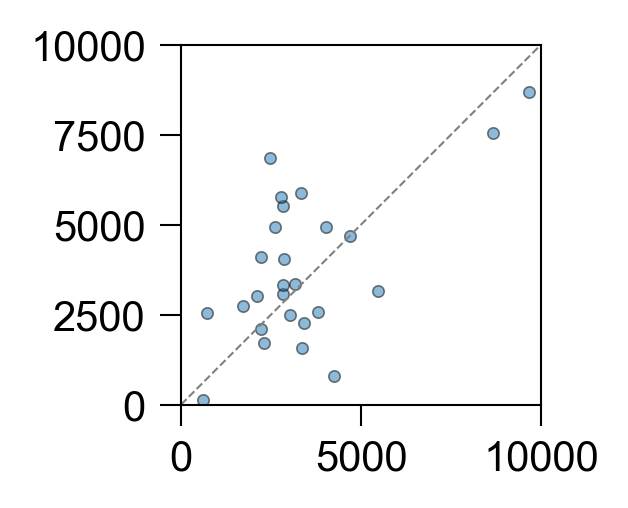

In [145]:
# let us do it without test/train split
tmp = df_var[['length', 'GS', 'EK', 'P', 'A', 'helix_panelty', 'high_corrected','fc_var', 'low_corrected']]

# Start up a new folder to store data and evaluation
var_num = 5
predict_target = 'low_corrected'

# define X, Y
X = tmp.iloc[:,:var_num]
Y = tmp[predict_target]

reg = LinearRegression().fit(X, Y)
print(reg.score(X, Y))

# make prediction
Y_pred = reg.predict(X)

fig_height = 1.5
fig_width = 1.5

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define points for the diagonal line
x = [0, 10000]
y = [0, 10000]

# Plot the dashed line
plt.plot(x, y, linestyle='--', color='grey', linewidth=.5)

# Plot y_predict
plt.scatter(x=Y, y=Y_pred,
            alpha=.5, edgecolor='k', linewidth=0.4, s=7.5,)

plt.xlim(0,10000)
plt.ylim(0,10000)

low_model = reg

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# Save
plt.savefig(root+'baseline_model.svg')
plt.show()
plt.close('all') # clean up after using pyplot

### Maximum activation linear regression with experimental data

0.759876057197154


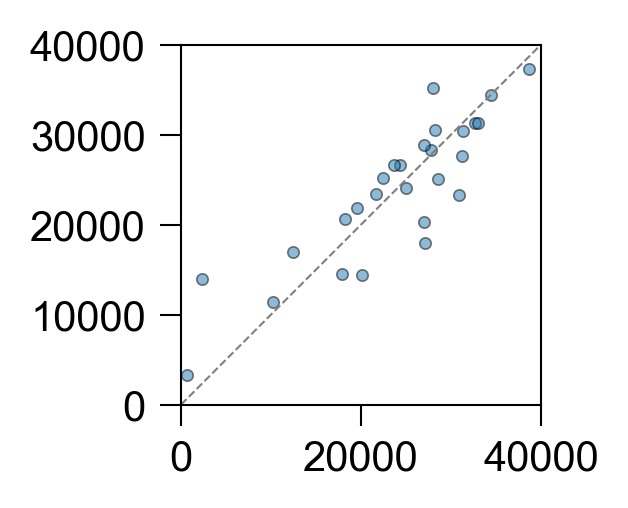

In [143]:
# let us do it without test/train split
tmp = df_var[['length', 'GS', 'EK', 'P', 'A', 'helix_panelty', 'high_corrected','fc_var', 'low_corrected']]

# Start up a new folder to store data and evaluation
var_num = 5
predict_target = 'high_corrected'

# define X, Y
X = tmp.iloc[:,:var_num]
Y = tmp[predict_target]

reg = LinearRegression().fit(X, Y)
print(reg.score(X, Y))

# make prediction
Y_pred = reg.predict(X)

fig_height = 1.5
fig_width = 1.5

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# Define points for the diagonal line
x = [0, 40000]
y = [0, 40000]

# Plot the dashed line
plt.plot(x, y, linestyle='--', color='grey', linewidth=.5)

# Plot y_predict
plt.scatter(x=Y, y=Y_pred,
            alpha=.5, edgecolor='k', linewidth=0.4, s=7.5,)

plt.xlim(0,40000)
plt.ylim(0,40000)

high_model = reg

# Save
plt.savefig(root+'max_activation_model.svg')
plt.show()
plt.close('all') # clean up after using pyplot

### Calculate the feature of each sequence

In [ ]:
# Useful function to extract feature from hinge sequences
# Make a column of helical panelty
# Load the reference for helical penalty
helix_ref = pd.read_excel(
    '/Users/cqh/Desktop/Fig2/Linker_mini_screen/helical_panelty_ref.xlsx',)

# Useful functions
def amino_acid_count(x):
    """get amino acid counts for a given sequence string
    """
    freq = {}
    for c in set(x):
       freq[c] = x.count(c)
    return freq

def get_seq_helix_panelty(pr, helix_ref):
    """get a total panelty value for a given sequence string
    """
    seq = amino_acid_count(pr)
    res = 0
    for aa in list(seq.keys()):
        tmp = float(
            helix_ref[helix_ref['1-letter']==aa]['helical_panelty(kj/mol)'])
        res += seq[aa]*tmp
    return res

def get_aa_freq(aa, x):
    """get the amino acid percentage for a certain aa in a sequence string
    """
    length = len(x)    # get the total length of the string
    freq = amino_acid_count(x)  # get a dict of aa in this string
    
    if aa in list(freq.keys()):
        return freq[aa]/length
    else:
        return 0/length


### Generate a virtual library of hinge sequences

In [ ]:
# cat 1: generate rand flexible linker with SAGT of different length
seq = []
kind = []
for l in np.arange(5,120):
    for i in range(10):
        seq.append(flexible_rand_generator(l, weight=[25, 25, 25, 25], flex_pool=flex_pool, seed=None))
        kind.append('rand_flex')

#  cat 2: generate SAGG repeats
motif = 'SAGG'
for i in range(50):
    seq.append(motif_repeat(motif, i))
    kind.append('SAGG_repeats')

# cat 3: generate XP repeats and its mutants toward GS or EAAAK
for l in np.arange(2,100):
    for i in range(10):
        tmp_seq = xp_rand_generator(l, x_pool='A', weight=[100], seed=None)
        seq.append(tmp_seq)
        kind.append('AP_repeats')
        seq.append(percentage_mutation(tmp_seq, percentage=0.25, sub_pool=flex_pool))
        kind.append('AP_twd_GS_0.25')
        seq.append(percentage_mutation(tmp_seq, percentage=0.5, sub_pool=flex_pool))
        kind.append('AP_twd_GS_0.5')
        seq.append(percentage_mutation(tmp_seq, percentage=0.75, sub_pool=flex_pool))
        kind.append('AP_twd_GS_0.75')
        
        
# cat 4:EAAAK repeats
motif = 'EAAAK'
for l in range(20):
    for i in range(20):
        tmp_seq = motif_repeat(motif, l)
        seq.append(tmp_seq)
        kind.append('EAAAK_repeats')
        seq.append(percentage_mutation(tmp_seq, percentage=0.25, sub_pool=flex_pool))
        kind.append('EAAAK_twd_GS_0.25')
        seq.append(percentage_mutation(tmp_seq, percentage=0.5, sub_pool=flex_pool))
        kind.append('EAAAK_twd_GS_0.5')
        seq.append(percentage_mutation(tmp_seq, percentage=0.75, sub_pool=flex_pool))
        kind.append('EAAAK_twd_GS_0.75')
        seq.append(percentage_mutation(tmp_seq, percentage=0.1, sub_pool='P'))
        kind.append('EAAAK_twd_AP_0.1')
        seq.append(percentage_mutation(tmp_seq, percentage=0.9, sub_pool='P'))
        kind.append('EAAAK_twd_AP_0.9')
    
# cat 5:random helix linkers
for l in np.arange(1,20):
    for i in range(10):
        seq.append(helical_motif_repeat(l))
        kind.append('rand_helix_repeats')


In [ ]:
dum = pd.DataFrame(columns=['length', 'GS', 'EK', 'P', 'A', 'high_predict','low_predict', 'seq'])

dum['seq']=seq
dum['kind']=kind
dum['length'] = [len(x) for x in dum['seq']]
dum = dum[dum['length']>0]
dum['A'] = [get_aa_freq('A', x) for x in dum['seq']]
dum['P'] = [get_aa_freq('P', x) for x in dum['seq']]
dum['GS'] = [get_aa_freq('G', x)+get_aa_freq('S', x) for x in dum['seq']]
dum['EK'] = [get_aa_freq('E', x)+get_aa_freq('K', x) for x in dum['seq']]

dum.to_csv(root+'Linker_mini_screen_input.csv')

X = dum.iloc[:,:5]
dum['high_predict'] = high_model.predict(X)
dum['low_predict'] = low_model.predict(X)
dum['fc'] = dum['high_predict']/dum['low_predict']

### Use the models to predict max activation and bkgd activation for all virtual sequences

##### Recaptulate the pattern of length
when computationally mutate EAAAK helical hinges to GS-rich flexible hinges

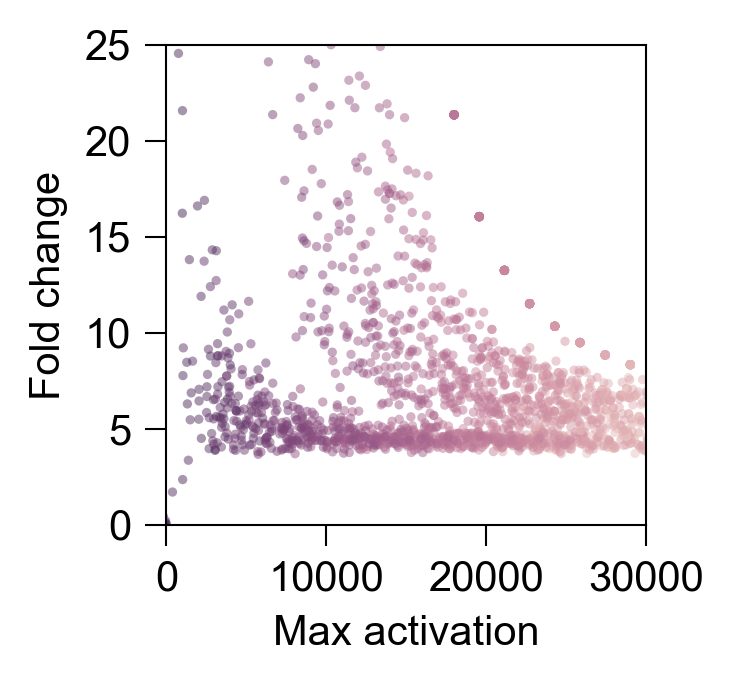

In [ ]:
fig_height = 2
fig_width = 2

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define hue order
order =['EAAAK_repeats','EAAAK_twd_GS_0.25', 'EAAAK_twd_GS_0.5', 'EAAAK_twd_GS_0.75',
        'rand_flex']

# Define the custom color palette
palette  = 'rocket_r'

# scatter the points with different properties
ax = sns.scatterplot(data=dum[dum['kind'].isin(order)], 
                 x='high_predict', y='fc', 
                 hue='length', 
                 hue_norm=(0,120),
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# set limits
plt.xlim([0,30000])
plt.ylim([0,25])

# Customizing the plot
ax.set_xlabel('Max activation')
ax.set_ylabel('Fold change')

# remove legend
ax.get_legend().remove()
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))



# Save
plt.savefig(root+'EAAAK_to_GS_mut.svg')
plt.show()
plt.close('all') # clean up after using pyplot

##### Recaptulate the pattern of length
when computationally mutate AP-rich hinges to GS-rich flexible hinges

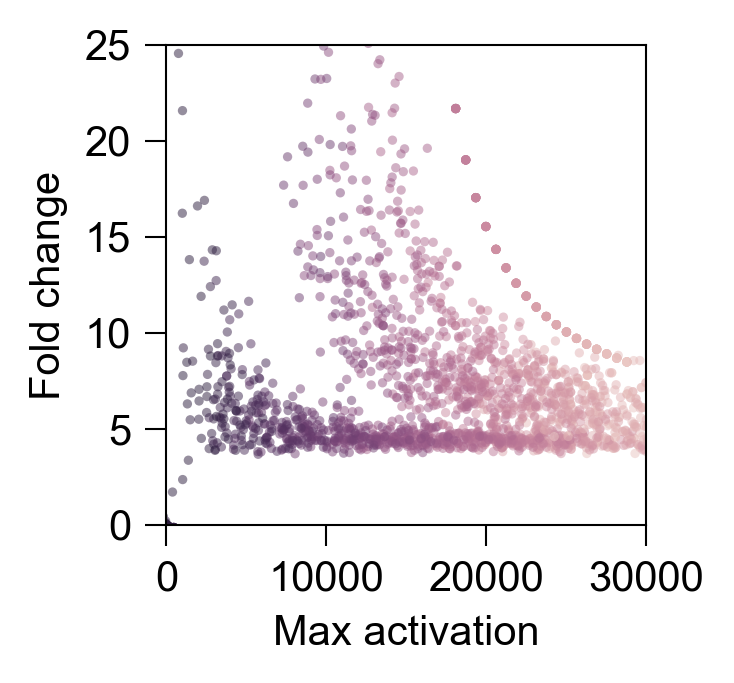

In [ ]:
fig_height = 2
fig_width = 2

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define hue order
order =['AP_repeats','AP_twd_GS_0.25', 'AP_twd_GS_0.5', 'AP_twd_GS_0.75',
        'rand_flex']

# Define the custom color palette
palette  = sns.cubehelix_palette(as_cmap=True)
cmap = palette

# Define hue norm
norm = mcolors.Normalize(vmin=0, vmax=100)

# scatter the points with different properties
ax = sns.scatterplot(data=dum[dum['kind'].isin(order)], 
                 x='high_predict', y='fc', 
                 hue='length',
                 hue_norm=norm,
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# set limits
plt.xlim([0,30000])
plt.ylim([0,25])

# Customizing the plot
ax.set_xlabel('Max activation')
ax.set_ylabel('Fold change')

# remove legend
ax.get_legend().remove()

# Save
plt.savefig(root+'AP_to_GS_length.svg')
plt.show()
plt.close('all') # clean up after using pyplot

##### Recaptulate the pattern of hinge property
when computationally mutate EAAAK hinges to GS-rich flexible hinges

/var/folders/5_/cdqlkh7j7rb7797sl95mc6mc0000gn/T/ipykernel_7844/910157163.py:27: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.scatterplot(data=dum[dum['kind'].isin(order)],


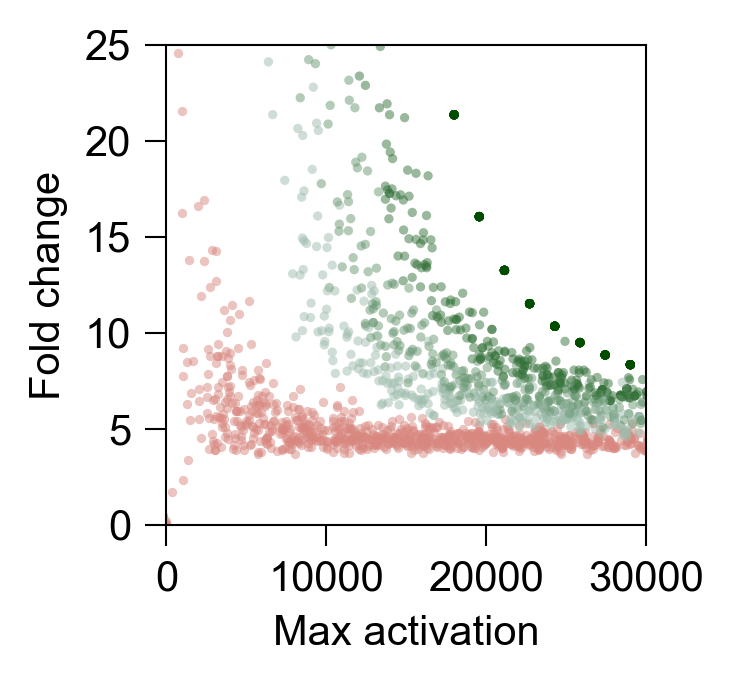

In [129]:
fig_height = 2
fig_width = 2

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define hue order
order = ['EAAAK_repeats','EAAAK_twd_GS_0.25', 'EAAAK_twd_GS_0.5', 'EAAAK_twd_GS_0.75']

# Define the custom color palette
palette = ['#004D00', '#35723A', '#6A9873', '#9EBDAD', '#D98880']


# scatter the points with different properties
ax = sns.scatterplot(data=dum[dum['kind']=='rand_flex'], 
                 x='high_predict', y='fc', color=palette[-1], 
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

ax = sns.scatterplot(data=dum[dum['kind'].isin(order)], 
                 x='high_predict', y='fc', palette=palette, 
                 hue='kind', hue_order=order,
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# set limits
plt.xlim([0,30000])
plt.ylim([0,25])

# Customizing the plot
ax.set_xlabel('Max activation')
ax.set_ylabel('Fold change')

# remove legend
ax.get_legend().remove()
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Save
plt.savefig(root+'multi_mut_from_EAAAK_to_GS.png')
plt.show()
plt.close('all') # clean up after using pyplot

##### Recaptulate the pattern of hinge property
when computationally mutate AP hinges to GS-rich flexible hinges

/var/folders/5_/cdqlkh7j7rb7797sl95mc6mc0000gn/T/ipykernel_7844/730786777.py:28: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.scatterplot(data=dum[dum['kind'].isin(order)],


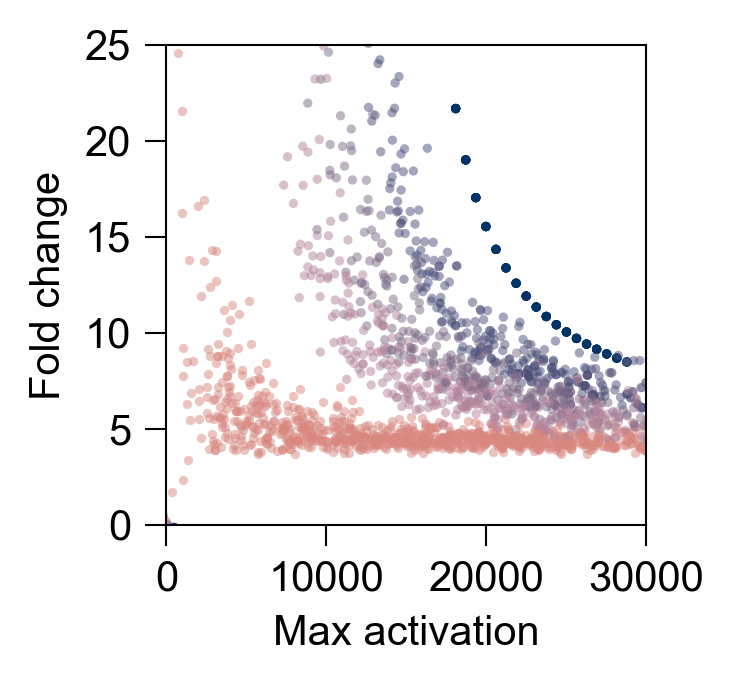

In [130]:
fig_height = 2
fig_width = 2

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define hue order
order = ['AP_repeats','AP_twd_GS_0.25', 'AP_twd_GS_0.5', 'AP_twd_GS_0.75']

# Define the custom color palette
palette = ['#003366', '#4B4F78', '#7F6C89', '#B3859B', '#D98880']



# scatter the points with different properties
ax = sns.scatterplot(data=dum[dum['kind']=='rand_flex'], 
                 x='high_predict', y='fc', color=palette[-1], 
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

ax = sns.scatterplot(data=dum[dum['kind'].isin(order)], 
                 x='high_predict', y='fc', palette=palette, 
                 hue='kind', hue_order=order,
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# set limits
plt.xlim([0,30000])
plt.ylim([0,25])

# Customizing the plot
ax.set_xlabel('Max activation')
ax.set_ylabel('Fold change')

# remove legend
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.get_legend().remove()

# Save
plt.savefig(root+'multi_mut_from_AP_to_GS.svg')
plt.show()
plt.close('all') # clean up after using pyplot

##### Plot for EAAAK, Pro-rich and flexible hinge performance in the same plot

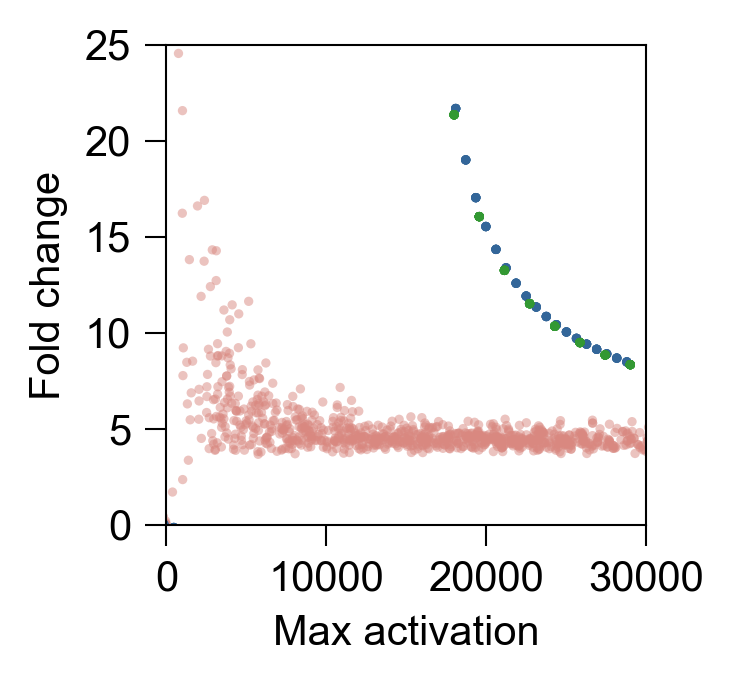

In [150]:
fig_height = 2
fig_width = 2

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define hue order
order = ['EAAAK_repeats','AP_repeats', 'rand_flex']

# Define the custom color palette
palette = ['#004D00', '#003366', '#D98880']
palette = ['#339933', '#336699', '#D98880']

# scatter the points with different properties
ax = sns.scatterplot(data=dum[dum['kind'].isin(order)], 
                 x='high_predict', y='fc', palette=palette, 
                 hue='kind', hue_order=order,
                alpha=.5, edgecolor='w', linewidth=0., s=5,
                )

# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='major', width=.5, size=5,)
ax.tick_params(which='minor', width=.5, size=2)
# ax.spines[['right', 'top']].set_visible(False)

# set limits
plt.xlim([0,30000])
plt.ylim([0,25])

# Customizing the plot
ax.set_xlabel('Max activation')
ax.set_ylabel('Fold change')

# remove legend
ax.get_legend().remove()
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Save
plt.savefig(root+'multi_mut_schematic.svg')
plt.show()
plt.close('all') # clean up after using pyplot